# Agreement Risk Scanner

## Detecting Unfair Terms of Service Clauses

This project develops a supervised machine learning system that identifies potentially unfair clauses in Terms of Service agreements.

The system operates at the sentence level. Each sentence is classified into a risk category, allowing potentially important clauses to be identified and explained to the user.

The project focuses on consumer online platforms such as social media, streaming services, cloud storage, and e-commerce platforms.

## Problem Definition

Terms of Service documents contain large amounts of legal and contractual language. Important clauses can be difficult for ordinary users to identify because they are surrounded by lengthy and complex text.

This project treats the problem as supervised text classification.

The input to the model is a sentence extracted from a Terms of Service document.

The output is a risk category assigned to that sentence.

The model will be trained using sentences that have already been annotated by researchers.

## Classification Categories

The project groups the annotated clauses into the following risk categories:

| Category | Description |
|---|---|
| None | Fair or standard clauses |
| Limitation of Liability | Clauses that limit or exclude the company's liability |
| Unilateral Termination | Clauses allowing the company to suspend or terminate an account |
| Unilateral Change | Clauses allowing the company to change the terms unilaterally |
| Content Removal | Clauses allowing the company to remove user content |
| Other Risk | Other potentially unfair clauses outside the four main categories |

## Dataset

The dataset used for this project is the CLAUDETTE-derived Terms of Service dataset.

It contains sentences extracted from Terms of Service documents and annotated according to whether they contain potentially unfair contractual clauses.

The dataset provides the labelled examples required for supervised machine learning.

Before preprocessing or modelling, the dataset will be inspected to verify its structure, labels, class distribution, missing values, duplicates, and other data quality characteristics.

## Import the Required Libraries

The notebook will use a small set of Python libraries throughout the machine learning workflow.

Pandas will handle the dataset and tabular analysis. NumPy will support numerical operations where required. Matplotlib and Seaborn will be used for exploratory visualizations. Scikit-learn will provide the preprocessing, feature extraction, model training, and evaluation tools used later in the project.

The imports are grouped together because they form the initial environment required for the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Load the Dataset

The raw dataset is stored in the `data/raw` directory so that the original downloaded file remains unchanged throughout the project.

The purpose of this step is simply to establish the raw dataset that will be investigated in the following sections.

In [6]:
dataset_path = Path("../data/raw/ToS-100-cleaned.csv")
df = pd.read_csv(dataset_path)

## Verify the Dataset

Before beginning the analysis, we will perform a minimal check that the dataset was loaded successfully.

In [7]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (20417, 7)


## Dataset Structure

The structure of the dataset is examined to identify the available variables, their data types, and the number of non-null observations in each column.

This provides an initial assessment of the information available for text classification and identifies fields that may require preprocessing.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20417 entries, 0 to 20416
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text                    20417 non-null  object
 1   FAIR                    20417 non-null  int64 
 2   REMOVE_CONTENT          20417 non-null  int64 
 3   UNBALANCED_DELECRATION  20417 non-null  int64 
 4   TERMINATE_CONTRACT      20417 non-null  int64 
 5   OTHER                   20417 non-null  int64 
 6   label                   20417 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 1.1+ MB


## Label Representation

The dataset contains separate indicator columns for the annotated clause categories, together with a numeric `label` field.

The indicator columns will be examined to determine how the original annotations are represented and how the `label` field relates to them.

Understanding this structure is necessary before defining the target variable for supervised classification.

In [9]:
label_columns = [
    "FAIR",
    "REMOVE_CONTENT",
    "UNBALANCED_DELECRATION",
    "TERMINATE_CONTRACT",
    "OTHER"
]

df[label_columns].sum()

FAIR                      18235
REMOVE_CONTENT              216
UNBALANCED_DELECRATION      705
TERMINATE_CONTRACT          653
OTHER                       608
dtype: int64

## Verify Annotation Exclusivity

The category indicators account for every observation in the dataset.

The indicators will be checked at the row level to determine whether each sentence belongs to exactly one annotated category. This establishes whether the columns represent mutually exclusive class assignments.

In [10]:
indicator_counts = df[label_columns].sum(axis=1)

print(indicator_counts.value_counts().sort_index())

1    20417
Name: count, dtype: int64


## Inspect the Encoded Label

The `label` column is stored as an integer and may represent the categorical annotation encoded numerically.

Its unique values and frequencies will be examined to determine whether it corresponds directly to the five annotation categories identified above.

In [11]:
df["label"].value_counts().sort_index()

label
0    18235
1      216
2      705
3      653
4      608
Name: count, dtype: int64

## Verify the Label Encoding

The frequency of each numeric label matches the corresponding annotation category.

To confirm the encoding, each numeric label will be compared with the active indicator column for every sentence. A complete match will establish that the `label` column is a reliable encoded representation of the categorical annotations.

In [12]:
label_mapping = dict(enumerate(label_columns))

expected_labels = df[label_columns].to_numpy().argmax(axis=1)
labels_match = (df["label"].to_numpy() == expected_labels).all()

print(f"Label encoding verified: {labels_match}")
print(f"Label mapping: {label_mapping}")

Label encoding verified: True
Label mapping: {0: 'FAIR', 1: 'REMOVE_CONTENT', 2: 'UNBALANCED_DELECRATION', 3: 'TERMINATE_CONTRACT', 4: 'OTHER'}


## Inspect the Text Data

The `text` field contains the sentence-level input used by the classifier.

A small sample of the text is examined to understand the type of language represented in the dataset and confirm that the observations correspond to individual Terms of Service clauses.

In [13]:
df["text"].head(5)

0               websites & communications terms of use
1    please read the terms of this entire document ...
2    by accessing or signing up to receive communic...
3    our websites include multiple domains such as ...
4    you may also recognize our websites by nicknam...
Name: text, dtype: object

## Assess Text Completeness

The text field is the primary input to the classifier, so each observation must contain usable text.

The dataset will be checked for missing values and empty or whitespace-only entries before text preprocessing begins.

In [14]:
missing_text = df["text"].isna().sum()
empty_text = df["text"].fillna("").str.strip().eq("").sum()

print(f"Missing text: {missing_text}")
print(f"Empty text: {empty_text}")

Missing text: 0
Empty text: 0


## Check for Duplicate Sentences

Duplicate sentences can cause data leakage when identical observations are distributed across the training and test sets.

The text field will be checked for exact duplicate sentences to determine whether duplicate observations are present in the dataset.`

In [15]:
duplicate_count = df["text"].duplicated().sum()

print(f"Duplicate sentences: {duplicate_count}")

Duplicate sentences: 502


## Examine Duplicate Labels

Duplicate sentences are present in the dataset. Their associated labels will be examined to determine whether identical sentences consistently receive the same classification.

Consistent labels allow duplicates to be safely removed before splitting the data. Conflicting labels would require further investigation because the same text would have different target values.`

In [16]:
duplicate_rows = df[df["text"].duplicated(keep=False)]

duplicate_label_counts = (
    duplicate_rows.groupby("text")["label"]
    .nunique()
)

print(f"Duplicated sentences: {duplicate_rows['text'].nunique()}")
print(f"Conflicting duplicate groups: {(duplicate_label_counts > 1).sum()}")

Duplicated sentences: 459
Conflicting duplicate groups: 10


## Inspect Conflicting Duplicate Annotations

A small number of duplicated sentences have conflicting labels.

These observations will be inspected before deciding how to handle duplicates. The review will show the repeated sentence, its assigned labels, and the number of occurrences for each label.

In [17]:
conflicting_texts = duplicate_label_counts[duplicate_label_counts > 1].index

conflicting_duplicates = (
    df[df["text"].isin(conflicting_texts)]
    .groupby(["text", "label"])
    .size()
    .reset_index(name="count")
    .sort_values("text")
)

conflicting_duplicates

,text,label,count
0,either party may bring a lawsuit solely for in...,0,1
1,either party may bring a lawsuit solely for in...,2,1
2,"if these laws apply to you , some or all of th...",0,2
3,"if these laws apply to you , some or all of th...",2,1
4,"if you do not agree to the modifications , you...",0,1
5,"if you do not agree to the modifications , you...",4,1
6,if you repeatedly infringe other people 's int...,0,1
7,if you repeatedly infringe other people 's int...,3,1
9,"if your claim exceeds $ 10,000 , the right to ...",2,1
8,"if your claim exceeds $ 10,000 , the right to ...",0,1


## Quantify Duplicate Observations

Duplicate analysis identified repeated sentences, including a small number with conflicting annotations.

The total number of observations belonging to duplicate groups is measured to determine the extent of duplication in the dataset.

In [18]:
duplicate_row_count = len(duplicate_rows)

print(f"Rows belonging to duplicate groups: {duplicate_row_count}")

Rows belonging to duplicate groups: 961


## Duplicate Handling Strategy

Duplicate observations can introduce data leakage when identical sentences appear in both training and test sets.

Duplicate groups with conflicting labels cannot provide a consistent supervised-learning target and will be removed.

For duplicate groups with consistent labels, only one occurrence of each sentence will be retained.

This produces a deduplicated dataset in which each unique sentence has a single target label before the train/test split.

In [19]:
conflicting_texts = set(conflicting_texts)

clean_df = df[~df["text"].isin(conflicting_texts)].drop_duplicates(
    subset="text",
    keep="first"
).copy()

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(clean_df)}")
print(f"Rows removed: {len(df) - len(clean_df)}")

Original rows: 20417
Cleaned rows: 19905
Rows removed: 512


## Verify Duplicate Removal

The cleaned dataset should contain one occurrence of each sentence and no unresolved annotation conflicts.

The duplicate count is checked again to confirm that the cleaning process produced a unique text.

In [20]:
remaining_duplicates = clean_df["text"].duplicated().sum()

print(f"Remaining duplicate sentences: {remaining_duplicates}")

Remaining duplicate sentences: 0


## Class Distribution After Cleaning

The class distribution is examined after duplicate removal to determine the composition of the final modelling dataset.

This establishes the prevalence of each target class and quantifies the degree of class imbalance that must be considered during model training and evaluation.

In [21]:
class_distribution = clean_df["label"].value_counts().sort_index()

class_distribution

label
0    17762
1      215
2      688
3      647
4      593
Name: count, dtype: int64

## Class Proportions

Class proportions are calculated to quantify the distribution of the target variable after data cleaning.

The proportions provide a clearer measure of class imbalance than raw counts alone and will inform the choice of training and evaluation strategies.

In [22]:
class_proportions = (
    clean_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_proportions

label
0    89.23
1     1.08
2     3.46
3     3.25
4     2.98
Name: proportion, dtype: float64

## Text Length Analysis

The length of each text observation is measured to understand the distribution of sentence sizes in the dataset.

Sentence length provides an initial view of the textual data and can reveal unusually short or long observations that may affect later feature extraction.

In [23]:
text_length = clean_df["text"].str.len()

print(f"Minimum length: {text_length.min()}")
print(f"Median length: {text_length.median()}")
print(f"Mean length: {text_length.mean():.1f}")
print(f"Maximum length: {text_length.max()}")

Minimum length: 13
Median length: 146.0
Mean length: 181.2
Maximum length: 2023


## Text Length Distribution

The distribution of text lengths is visualized to assess the overall spread of sentence sizes and identify potential extreme observations.

The distribution provides more context than summary statistics alone and helps determine whether additional length-based preprocessing is necessary.

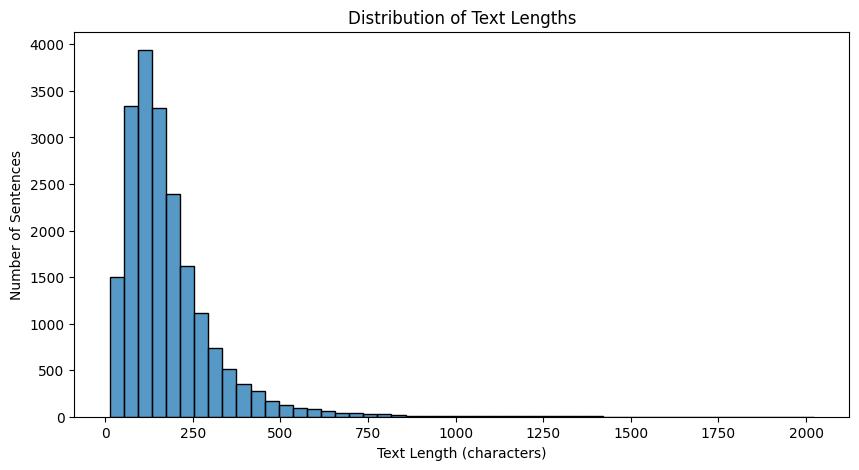

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(text_length, bins=50)
plt.xlabel("Text Length (characters)")
plt.ylabel("Number of Sentences")
plt.title("Distribution of Text Lengths")
plt.show()

## Text Length Findings

Text length is concentrated in the lower range, with a right-skewed distribution and a smaller number of substantially longer observations.

The observed variation is compatible with sentence-level Terms of Service data. No length-based filtering is applied at this stage because the longer observations may contain valid contractual information relevant to classification.

## Inspect Text Length Extremes

The shortest and longest observations are reviewed to determine whether extreme text lengths correspond to valid Terms of Service content.

This qualitative check complements the numerical and graphical analysis and helps identify observations that may require special treatment during preprocessing.

In [25]:
shortest_text = clean_df.loc[text_length.nsmallest(5).index, "text"]
longest_text = clean_df.loc[text_length.nlargest(5).index, "text"]

print("Shortest observations:")
print(shortest_text.to_string(index=False))

print("\nLongest observations:")
print(longest_text.to_string(index=False))

Shortest observations:
          b , 2.c , 3 .
      / / end terms / /
   also , do n't spam .
new york , ny , 10003 ,
who is `` customer '' ?

Longest observations:
however and to the extent permitted by law , ne...
prohibited user content includes content that :...
you will not , and will make sure that the plat...
under no circumstances will the instagram parti...
you expressly understand and agree that evernot...


## Inspect Text Normalization

The text is reviewed for formatting patterns introduced during dataset preparation, including tokenized punctuation and special markers.

These patterns are assessed before preprocessing so that useful linguistic information is not removed unnecessarily.

In [26]:
special_patterns = {
    "contractions_split": clean_df["text"].str.contains(r"\b\w+\s+n['’]t\b", regex=True).sum(),
    "parenthesis_markers": clean_df["text"].str.contains(r"-lrb-|-rrb-", regex=True).sum(),
    "bracket_markers": clean_df["text"].str.contains(r"-lsb-|-rsb-", regex=True).sum(),
}

pd.Series(special_patterns)

contractions_split      198
parenthesis_markers    4192
bracket_markers          24
dtype: int64

## Text Length by Class

Text length is compared across the five target classes to determine whether substantial differences exist between categories.

The comparison provides additional context about the structure of the classification problem and helps identify whether particular classes tend to contain systematically shorter or longer text observations.

In [27]:
class_length_summary = (
    clean_df.assign(text_length=text_length)
    .groupby("label")["text_length"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
)

class_length_summary

,count,mean,median,min,max
label,,,,,
0,17762,175.0,142.0,13,1843
1,215,247.3,202.0,45,1197
2,688,306.2,243.0,32,2023
3,647,180.2,151.0,26,1151
4,593,199.0,167.0,40,809


## Create the Modelling Dataset

The cleaned dataset contains the unique, consistently labelled observations that will be used for supervised learning.

Only the text and verified numeric target label are retained for modelling. The original annotation indicator columns are excluded because they directly encode the target information and would introduce target leakage if used as features.

In [28]:
model_df = clean_df[["text", "label"]].copy()

print(f"Modelling rows: {len(model_df)}")
print(f"Modelling columns: {model_df.shape[1]}")

Modelling rows: 19905
Modelling columns: 2


## Text Preprocessing

The text is normalized to create a consistent representation for feature extraction.

Preprocessing includes lowercasing, conversion of dataset-specific punctuation markers to their standard forms, and normalization of excessive whitespace.

Aggressive punctuation and stopword removal are avoided because legal expressions and short function words can contribute meaningful information to clause classification.

In [29]:
def preprocess_text(text):
    replacements = {
        "-lrb-": "(",
        "-rrb-": ")",
        "-lsb-": "[",
        "-rsb-": "]"
    }

    text = text.lower()

    for old, new in replacements.items():
        text = text.replace(old, new)

    return " ".join(text.split())


model_df["text_clean"] = model_df["text"].map(preprocess_text)

## Verify Preprocessed Text

A small sample of the original and processed text is compared to confirm that normalization changes only the intended formatting while preserving the underlying clause content.

In [30]:
model_df[["text", "text_clean"]].head(5)

,text,text_clean
0,websites & communications terms of use,websites & communications terms of use
1,please read the terms of this entire document ...,please read the terms of this entire document ...
2,by accessing or signing up to receive communic...,by accessing or signing up to receive communic...
3,our websites include multiple domains such as ...,our websites include multiple domains such as ...
4,you may also recognize our websites by nicknam...,you may also recognize our websites by nicknam...


## Prepare the Train-Test Split

The cleaned observations are separated into training and test sets before model fitting.

A stratified 80/20 split is used so that each class retains approximately the same proportion in both sets. The test set is held aside for final evaluation and is not used to learn the text representation or classification model.

In [31]:
from sklearn.model_selection import train_test_split

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 15924
Test samples: 3981


## Configure TF-IDF Feature Extraction

TF-IDF converts the text observations into numerical features that can be used by the classifier.

Both unigrams and bigrams are included. Unigrams represent individual terms, while bigrams capture short phrases whose meaning may depend on word combinations.

Terms appearing in more than 95% of training documents are excluded because they provide little distinction between observations.

The vectorizer is fitted only on the training data to prevent information from the test set from influencing feature construction.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training matrix: {X_train_tfidf.shape}")
print(f"Test matrix: {X_test_tfidf.shape}")

Training matrix: (15924, 107139)
Test matrix: (3981, 107139)


## Train the Baseline Linear SVM

A linear Support Vector Machine is trained using the TF-IDF representations.

`LinearSVC` is used instead of `SVC(kernel="linear")` because TF-IDF produces a high-dimensional sparse feature matrix. `LinearSVC` is designed for efficient linear classification in this setting and avoids the additional computational cost of the general kernel-based SVM implementation.

Class-balanced weighting is applied so that errors on minority classes receive greater importance during training. This reduces the influence of the dominant FAIR class on the learned decision boundaries.

This model establishes the baseline against which subsequent model improvements and parameter changes will be evaluated.

In [33]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

print("Baseline SVM training complete.")

Baseline SVM training complete.


## Generate Test Predictions

The trained classifier is used to predict the labels of the held-out test observations.

The test set has not been used during feature fitting or model training, so these predictions provide an unbiased basis for evaluating the baseline model.

In [34]:
y_pred = svm_model.predict(X_test_tfidf)

print(f"Predictions generated: {len(y_pred)}")

Predictions generated: 3981


## Evaluate the Baseline Model

The baseline predictions are evaluated using macro-F1 and per-class precision, recall, and F1 scores.

Macro-F1 is used as the primary metric because it gives equal importance to all five classes despite their unequal frequencies. Per-class metrics provide additional detail about the model's ability to identify both the dominant FAIR class and the minority risk categories.

The evaluation is performed exclusively on the held-out test set.

In [35]:
from sklearn.metrics import classification_report, f1_score

macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Macro-F1: {macro_f1:.4f}")
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=label_columns,
    digits=4
))

Macro-F1: 0.7400

                        precision    recall  f1-score   support

                  FAIR     0.9645    0.9724    0.9685      3552
        REMOVE_CONTENT     0.7857    0.5116    0.6197        43
UNBALANCED_DELECRATION     0.6612    0.5797    0.6178       138
    TERMINATE_CONTRACT     0.7000    0.7597    0.7286       129
                 OTHER     0.7928    0.7395    0.7652       119

              accuracy                         0.9400      3981
             macro avg     0.7808    0.7126    0.7400      3981
          weighted avg     0.9384    0.9400    0.9387      3981



## Analyze Classification Errors

A confusion matrix is used to examine how predictions are distributed across the five classes.

The matrix identifies which categories are being confused with one another and provides a basis for targeted model improvement beyond the overall performance metrics.

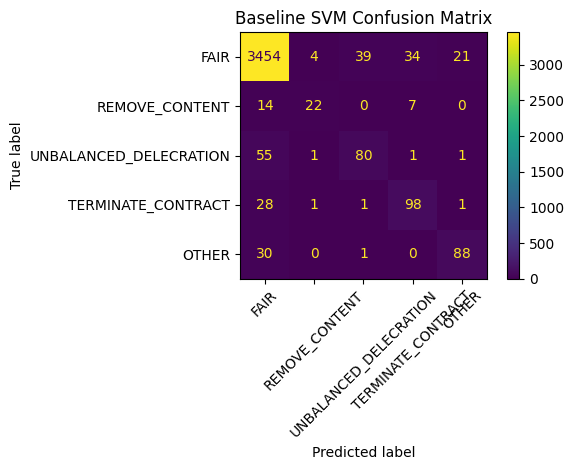

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_columns,
    xticks_rotation=45
)

plt.title("Baseline SVM Confusion Matrix")
plt.tight_layout()
plt.show()

## Interpret Learned Features

The strongest features learned by the baseline SVM show recognizable relationships between vocabulary and the target categories. Terms associated with content deletion, termination, liability, arbitration, and jurisdiction receive strong weights for their corresponding classes.

This indicates that the baseline is learning meaningful domain-specific language rather than relying only on the overall class frequencies.

However, the confusion matrix showed that many minority-class clauses are still being classified as FAIR. Because this is the main source of missed risk in the baseline, the next analysis examines representative false negatives to determine what types of language the model is failing to recognize.

In [37]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

false_negatives = error_df[
    (error_df["true_label"] != 0) &
    (error_df["predicted_label"] == 0)
].copy()

false_negatives["true_label"] = false_negatives["true_label"].map(
    dict(enumerate(label_columns))
)

false_negatives["predicted_label"] = false_negatives["predicted_label"].map(
    dict(enumerate(label_columns))
)

false_negatives.groupby("true_label").head(5)

,text,true_label,predicted_label
27,-lrb- f -rrb- any other commercial damages or ...,UNBALANCED_DELECRATION,FAIR
42,"in the event of such a breach , your right to ...",TERMINATE_CONTRACT,FAIR
60,"upon registration , the member accepts these t...",OTHER,FAIR
67,these terms & conditions -lrb- these `` terms ...,TERMINATE_CONTRACT,FAIR
73,"all policies , the mobile devices terms , and ...",OTHER,FAIR
112,if within 30 days following the notification o...,TERMINATE_CONTRACT,FAIR
125,"any dispute , conflict , claim or controversy ...",UNBALANCED_DELECRATION,FAIR
148,by visiting our website and accessing the info...,OTHER,FAIR
153,"for the sake of clarity , this includes any an...",UNBALANCED_DELECRATION,FAIR
245,in no case will the foregoing make us responsi...,UNBALANCED_DELECRATION,FAIR


## Normalize Corpus-Specific Text Markers

The error analysis shows that several risk clauses use meaningful legal language without relying on a single obvious keyword. At the same time, the learned feature inspection shows that dataset-specific markers such as `-lrb-` and `-rrb-` are entering the TF-IDF vocabulary as tokens.

Because these markers represent punctuation rather than meaningful legal concepts, they can add unnecessary features to the representation. The preprocessing is therefore refined to normalize these markers before TF-IDF feature extraction while preserving the surrounding legal language.

The baseline model is retained unchanged so that the effect of this preprocessing improvement can be measured directly.

In [38]:
improved_vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,
    lowercase=False,
    ngram_range=(1, 2),
    max_df=0.95
)

X_train_tfidf_clean = improved_vectorizer.fit_transform(X_train)
X_test_tfidf_clean = improved_vectorizer.transform(X_test)

print(f"Training matrix: {X_train_tfidf_clean.shape}")
print(f"Test matrix: {X_test_tfidf_clean.shape}")

Training matrix: (15924, 106599)
Test matrix: (3981, 106599)


## Train the Normalized-Text SVM

The refined TF-IDF representation is used to train a second Linear SVM with the same class-balancing strategy as the baseline.

The model configuration is kept unchanged so that the comparison isolates the effect of text normalization rather than combining multiple changes at once.

This provides a controlled experiment for determining whether removing corpus-specific formatting artifacts improves minority-class recognition.

In [39]:
improved_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

improved_svm.fit(X_train_tfidf_clean, y_train)

y_pred_improved = improved_svm.predict(X_test_tfidf_clean)

print("Normalized-text SVM training complete.")

Normalized-text SVM training complete.


## Compare Baseline and Normalized-Text Models

The normalized-text model is compared with the baseline using macro-F1 and per-class F1 scores.

The comparison determines whether the preprocessing change improves performance across the minority categories rather than only increasing the overall accuracy.

A change will be retained only if it provides meaningful improvement without sacrificing important risk-class performance.

In [40]:
baseline_f1 = f1_score(y_test, y_pred, average="macro")
improved_f1 = f1_score(y_test, y_pred_improved, average="macro")

print(f"Baseline Macro-F1:  {baseline_f1:.4f}")
print(f"Improved Macro-F1:  {improved_f1:.4f}")
print(f"Change:             {improved_f1 - baseline_f1:+.4f}")

Baseline Macro-F1:  0.7400
Improved Macro-F1:  0.7437
Change:             +0.0038


## Compare Per-Class Performance

The overall macro-F1 improvement is small, so the class-level results are examined before deciding whether to retain the normalization change.

Because macro-F1 gives equal weight to all classes, a small overall change may still represent a meaningful improvement for a minority category, or it may provide little practical benefit.

The baseline and normalized-text models are therefore compared using per-class F1 scores.

In [41]:
baseline_report = classification_report(
    y_test,
    y_pred,
    target_names=label_columns,
    output_dict=True
)

improved_report = classification_report(
    y_test,
    y_pred_improved,
    target_names=label_columns,
    output_dict=True
)

class_comparison = pd.DataFrame({
    "Baseline F1": [
        baseline_report[label]["f1-score"]
        for label in label_columns
    ],
    "Normalized F1": [
        improved_report[label]["f1-score"]
        for label in label_columns
    ]
}, index=label_columns)

class_comparison["Change"] = (
    class_comparison["Normalized F1"]
    - class_comparison["Baseline F1"]
)

class_comparison.round(4)

,Baseline F1,Normalized F1,Change
FAIR,0.9685,0.9692,0.0007
REMOVE_CONTENT,0.6197,0.6197,0.0000
UNBALANCED_DELECRATION,0.6178,0.6226,0.0048
TERMINATE_CONTRACT,0.7286,0.7313,0.0027
OTHER,0.7652,0.7759,0.0106


## Refine the TF-IDF Vocabulary

The normalization experiment produced only a small macro-F1 improvement, while the main minority-class errors remained largely unchanged.

The TF-IDF representation currently contains 107,139 features, including terms and phrases that may occur in very few training documents. Extremely rare features can provide weak generalization and increase the dimensionality of the representation.

Because the remaining errors are concentrated in minority-class recognition, the next experiment introduces a minimum document-frequency threshold to remove features that occur too rarely to provide reliable evidence.

The classifier and class-balancing strategy remain unchanged so that the effect of vocabulary reduction can be evaluated independently.

In [42]:
min_df=2

In [43]:
min_df_vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf_min_df = min_df_vectorizer.fit_transform(X_train)
X_test_tfidf_min_df = min_df_vectorizer.transform(X_test)

print(f"Training matrix: {X_train_tfidf_min_df.shape}")
print(f"Test matrix: {X_test_tfidf_min_df.shape}")

Training matrix: (15924, 44282)
Test matrix: (3981, 44282)


## Train the Reduced-Vocabulary SVM

The refined TF-IDF representation contains substantially fewer features after removing terms that occur in only one training document.

Because the previous model used the same Linear SVM configuration, the classifier configuration is kept unchanged. This isolates the effect of reducing the vocabulary and allows the resulting performance to be compared directly with the previous model.

In [44]:
min_df_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

min_df_svm.fit(X_train_tfidf_min_df, y_train)

y_pred_min_df = min_df_svm.predict(X_test_tfidf_min_df)

print("Reduced-vocabulary SVM training complete.")

Reduced-vocabulary SVM training complete.


## Evaluate the Reduced-Vocabulary Model

The reduced-vocabulary model is evaluated using macro-F1 and compared with the previous normalized-text model.

The comparison determines whether removing extremely rare features improves generalization while maintaining performance across the five classes.

The previous model is retained as the reference point so that each experiment builds on measured results rather than changing multiple components simultaneously.

In [45]:
min_df_f1 = f1_score(y_test, y_pred_min_df, average="macro")

print(f"Previous Macro-F1: {improved_f1:.4f}")
print(f"Reduced-vocabulary Macro-F1: {min_df_f1:.4f}")
print(f"Change: {min_df_f1 - improved_f1:+.4f}")

Previous Macro-F1: 0.7437
Reduced-vocabulary Macro-F1: 0.7473
Change: +0.0036


## Compare Reduced-Vocabulary Performance

The reduced-vocabulary model produced a small improvement in macro-F1 while substantially decreasing the number of TF-IDF features.

Because macro-F1 alone does not show how individual categories changed, the per-class F1 scores are compared with the previous model.

This comparison determines whether the improvement benefits the minority risk categories and whether any class experiences a meaningful performance loss.

In [46]:
min_df_report = classification_report(
    y_test,
    y_pred_min_df,
    target_names=label_columns,
    output_dict=True
)

min_df_comparison = pd.DataFrame({
    "Previous F1": [
        improved_report[label]["f1-score"]
        for label in label_columns
    ],
    "min_df=2 F1": [
        min_df_report[label]["f1-score"]
        for label in label_columns
    ]
}, index=label_columns)

min_df_comparison["Change"] = (
    min_df_comparison["min_df=2 F1"]
    - min_df_comparison["Previous F1"]
)

min_df_comparison.round(4)

,Previous F1,min_df=2 F1,Change
FAIR,0.9692,0.9689,-0.0003
REMOVE_CONTENT,0.6197,0.6486,0.0289
UNBALANCED_DELECRATION,0.6226,0.6255,0.0029
TERMINATE_CONTRACT,0.7313,0.7164,-0.0149
OTHER,0.7759,0.7773,0.0014


## Define the Tuning Pipeline

The previous experiments show that TF-IDF vocabulary settings affect minority-class performance, but the best setting is not yet clear.

Because changing one parameter at a time does not account for interactions between feature extraction and classifier regularization, a controlled hyperparameter search is used next.

The TF-IDF vectorizer and Linear SVM are placed inside a single pipeline so that every cross-validation fold learns its vocabulary and feature weights only from its corresponding training portion.

Macro-F1 is used as the optimization metric because all five target classes must contribute equally to model selection.

In [47]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_text,
        lowercase=False,
        ngram_range=(1, 2),
        max_df=0.95
    )),
    ("svm", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

print("Pipeline ready.")

Pipeline ready.


## Define the Hyperparameter Search

A focused hyperparameter search is performed over TF-IDF vocabulary filtering and SVM regularization.

`min_df` controls how frequently a term must occur before becoming a feature. `C` controls the strength of regularization in the SVM, affecting the trade-off between fitting the training data and maintaining a generalizable decision boundary.

`sublinear_tf` is also tested because logarithmic term-frequency scaling can reduce the influence of repeated terms in longer text.

The search is intentionally limited to a small, interpretable parameter space suitable for a high-dimensional sparse text classification problem.

In [48]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__sublinear_tf": [False, True],
    "svm__C": [0.5, 1, 2]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print(f"Configurations to evaluate: {24}")

Configurations to evaluate: 24


## Run Cross-Validation Search

The candidate configurations are evaluated using stratified three-fold cross-validation on the training set.

The held-out test set is not involved in this search. This prevents the final evaluation data from influencing hyperparameter selection and provides a cleaner estimate of how well the selected configuration is likely to generalize.

In [49]:
grid_search.fit(X_train, y_train)

print(f"Best cross-validation Macro-F1: {grid_search.best_score_:.4f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best cross-validation Macro-F1: 0.7510
Best parameters: {'svm__C': 0.5, 'tfidf__min_df': 1, 'tfidf__sublinear_tf': False}


## Evaluate the Selected Model

Cross-validation identified the best-performing configuration using only the training data.

The selected pipeline uses the TF-IDF and Linear SVM configuration identified during cross-validation. It is now evaluated on the held-out test set, which has remained completely separate from hyperparameter selection.

This final evaluation provides the appropriate comparison with the original baseline and determines whether the optimized configuration improves generalization to unseen clauses.

In [50]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_macro_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average="macro"
)

print(f"Final Test Macro-F1: {tuned_macro_f1:.4f}")
print(f"Baseline Test Macro-F1: {baseline_f1:.4f}")
print(f"Improvement: {tuned_macro_f1 - baseline_f1:+.4f}")

Final Test Macro-F1: 0.7533
Baseline Test Macro-F1: 0.7400
Improvement: +0.0133


## Select the Final Classical ML Model

The tuned Linear SVM achieved a test Macro-F1 of 0.7533, improving the original baseline from 0.7400 by 0.0133.

The improvement was obtained through controlled TF-IDF and SVM hyperparameter selection using stratified cross-validation, while the test set remained isolated until final evaluation.

In [51]:
final_model = best_model

print(f"Selected model: LinearSVC + TF-IDF")
print(f"Test Macro-F1: {tuned_macro_f1:.4f}")

Selected model: LinearSVC + TF-IDF
Test Macro-F1: 0.7533


## Evaluate the Selected Classical ML Model

The selected Linear SVM is evaluated using the same metrics applied to the baseline model.

Per-class precision, recall, and F1 scores are reported alongside Macro-F1 to show how performance is distributed across the five categories.

Comparing these results with the original baseline provides the final assessment of the improvement achieved through the modelling experiments.`

In [52]:
final_report = classification_report(
    y_test,
    y_pred_tuned,
    target_names=label_columns,
    digits=4
)

print(final_report)

                        precision    recall  f1-score   support

                  FAIR     0.9664    0.9710    0.9687      3552
        REMOVE_CONTENT     0.8065    0.5814    0.6757        43
UNBALANCED_DELECRATION     0.6535    0.6014    0.6264       138
    TERMINATE_CONTRACT     0.6809    0.7442    0.7111       129
                 OTHER     0.8053    0.7647    0.7845       119

              accuracy                         0.9405      3981
             macro avg     0.7825    0.7325    0.7533      3981
          weighted avg     0.9397    0.9405    0.9398      3981



## Analyze Final Classification Errors

The final confusion matrix is examined to determine whether the selected model reduced the minority-class errors identified during baseline analysis.

The matrix provides a class-by-class view of the remaining errors and shows which distinctions remain difficult for the classical text classification approach.

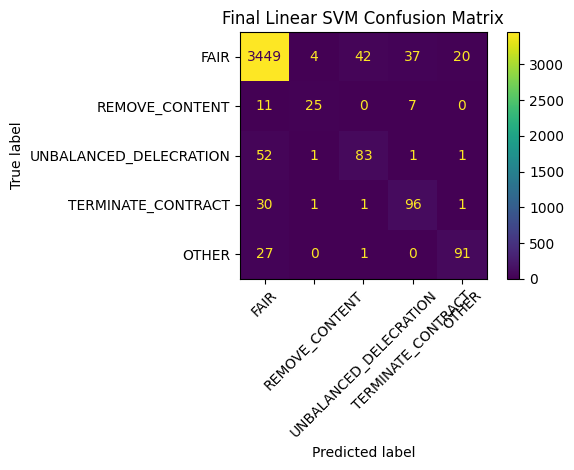

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=label_columns,
    xticks_rotation=45
)

plt.title("Final Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()

## Final Classical ML Findings

The classical text classification phase established a complete and reproducible machine learning pipeline for identifying risk categories in contractual language.

The dataset was first validated for missing values, class structure, duplicate observations, and text-length characteristics. Duplicate sentences were removed to prevent repeated observations from influencing model evaluation, while the severe class imbalance was addressed through class-balanced SVM weighting.

TF-IDF was then used to transform the contractual text into a high-dimensional sparse representation containing unigram and bigram features. A Linear Support Vector Machine was selected as the primary classifier because it is well suited to large sparse text representations.

The initial baseline achieved a Macro-F1 of 0.7400. Subsequent analysis examined model errors, learned features, text normalization, vocabulary filtering, and classifier hyperparameters. Controlled cross-validation was used to select the final configuration without exposing the held-out test set to model selection.

The selected model achieved a test Macro-F1 of 0.7533, representing an improvement of 0.0133 over the original baseline. The feature space was also reduced substantially during experimentation, demonstrating that effective text classification does not necessarily require retaining every observed term.

The final model performs particularly strongly on FAIR clauses, with an F1-score of 0.9687. Among the minority categories, REMOVE_CONTENT achieved an F1-score of 0.6757, UNBALANCED_DELECRATION 0.6264, TERMINATE_CONTRACT 0.7111, and OTHER 0.7845.

The confusion matrix shows that the dominant remaining error pattern is the classification of minority risk clauses as FAIR. This indicates that the most challenging cases contain language that is sufficiently similar to general contractual language that lexical TF-IDF features alone cannot consistently distinguish the underlying risk category.

Overall, the classical ML phase provides a validated benchmark, identifies the strengths and limitations of sparse lexical representations, and establishes a reliable foundation for the next modelling phase.

In [54]:
final_report_dict = classification_report(
    y_test,
    y_pred_tuned,
    target_names=label_columns,
    output_dict=True
)

final_summary = pd.DataFrame({
    "Precision": [
        final_report_dict[label]["precision"]
        for label in label_columns
    ],
    "Recall": [
        final_report_dict[label]["recall"]
        for label in label_columns
    ],
    "F1": [
        final_report_dict[label]["f1-score"]
        for label in label_columns
    ],
    "Support": [
        final_report_dict[label]["support"]
        for label in label_columns
    ]
}, index=label_columns)

final_summary.round(4)

,Precision,Recall,F1,Support
FAIR,0.9664,0.9710,0.9687,3552.0
REMOVE_CONTENT,0.8065,0.5814,0.6757,43.0
UNBALANCED_DELECRATION,0.6535,0.6014,0.6264,138.0
TERMINATE_CONTRACT,0.6809,0.7442,0.7111,129.0
OTHER,0.8053,0.7647,0.7845,119.0


## Classical ML Benchmark

The original baseline and final selected model are compared using Macro-F1. This benchmark establishes the performance reference that will be carried forward into subsequent modelling experiments.

In [55]:
classical_benchmark = pd.DataFrame({
    "Model": [
        "Baseline Linear SVM",
        "Final Tuned Linear SVM"
    ],
    "Macro-F1": [
        baseline_f1,
        tuned_macro_f1
    ]
})

classical_benchmark

,Model,Macro-F1
0,Baseline Linear SVM,0.739955
1,Final Tuned Linear SVM,0.753274


# Phase 2 : Agreement Risk Scanner

The modelling phase produced a validated Linear SVM classifier capable of assigning one of five risk categories to individual Terms of Service clauses.

The next phase converts the trained model into an inference pipeline. The pipeline accepts previously unseen contractual text, applies the same preprocessing and TF-IDF transformation used during training, and returns a predicted risk category for each clause.

Keeping preprocessing and feature transformation inside the trained pipeline ensures that new text is processed consistently with the data used to train the classifier.

## Restore the Selected Model

The final classifier was selected through cross-validated hyperparameter search.

The trained best estimator is retrieved directly from the completed grid search so that the same model configuration used for the final evaluation is also used for inference.

In [56]:
best_model = grid_search.best_estimator_
final_model = best_model

print(f"Selected model: LinearSVC + TF-IDF")
print(f"Test Macro-F1: {tuned_macro_f1:.4f}")

Selected model: LinearSVC + TF-IDF
Test Macro-F1: 0.7533


## Define the Clause Prediction Function

The final trained pipeline is used to classify previously unseen contractual clauses.

The function accepts raw clause text, applies the same TF-IDF transformation used during training, and returns the corresponding risk category predicted by the Linear SVM.

In [57]:
label_mapping = {
    0: "FAIR",
    1: "REMOVE_CONTENT",
    2: "UNBALANCED_DELECRATION",
    3: "TERMINATE_CONTRACT",
    4: "OTHER"
}

def predict_clause(text):
    prediction = best_model.predict([text])[0]
    return label_mapping[prediction]

## Test the Clause Classifier

The inference function is tested with representative contractual clauses from the risk categories.

These examples provide a simple functional check that the trained model can accept new text and return a valid category outside the original evaluation workflow.

In [58]:
test_clauses = [
    "We may terminate your account at any time without notice.",
    "We may remove any content that violates these terms.",
    "You agree to resolve all disputes through binding arbitration.",
    "We are not liable for any indirect or consequential damages.",
    "You may use the service subject to these terms."
]

for clause in test_clauses:
    print(f"{predict_clause(clause)}: {clause}")

TERMINATE_CONTRACT: We may terminate your account at any time without notice.
REMOVE_CONTENT: We may remove any content that violates these terms.
UNBALANCED_DELECRATION: You agree to resolve all disputes through binding arbitration.
UNBALANCED_DELECRATION: We are not liable for any indirect or consequential damages.
FAIR: You may use the service subject to these terms.


## Create Risk Category Explanations

A classification label is useful for machine evaluation but is not sufficient for a user-facing risk scanner.

Each predicted category is therefore mapped to a concise explanation describing the type of contractual language detected. These explanations provide a consistent interpretation layer between the machine-learning prediction and the eventual user interface.

In [59]:
risk_explanations = {
    "FAIR": "No specific high-risk contractual pattern was identified.",
    "REMOVE_CONTENT": "The clause gives the service provider authority to remove, restrict, or delete user content.",
    "UNBALANCED_DELECRATION": "The clause may limit liability or impose dispute-resolution obligations that could disadvantage the user.",
    "TERMINATE_CONTRACT": "The clause gives a party authority to suspend, modify, or terminate access or the agreement.",
    "OTHER": "The clause contains contractual language that may require additional review."
}

## Build the Clause-Level Risk Scanner

The prediction function is extended into a scanner that returns both the predicted risk category and its corresponding explanation.

This creates the core output structure required by the Agreement Risk Scanner: contractual text is transformed into an interpretable risk assessment rather than a classification label alone.

In [61]:
def scan_clause(text):
    category = predict_clause(text)

    return {
        "text": text,
        "risk_category": category,
        "explanation": risk_explanations[category]
    }

## Test the Complete Risk Assessment

The complete scanner is tested on representative contractual clauses to verify that each prediction produces both a risk category and a user-readable explanation.

This establishes the interface that will later be applied to complete Terms of Service documents.

In [62]:
for clause in test_clauses:
    result = scan_clause(clause)

    print(f"Risk: {result['risk_category']}")
    print(f"Explanation: {result['explanation']}")
    print()

Risk: TERMINATE_CONTRACT
Explanation: The clause gives a party authority to suspend, modify, or terminate access or the agreement.

Risk: REMOVE_CONTENT
Explanation: The clause gives the service provider authority to remove, restrict, or delete user content.

Risk: UNBALANCED_DELECRATION
Explanation: The clause may limit liability or impose dispute-resolution obligations that could disadvantage the user.

Risk: UNBALANCED_DELECRATION
Explanation: The clause may limit liability or impose dispute-resolution obligations that could disadvantage the user.

Risk: FAIR
Explanation: No specific high-risk contractual pattern was identified.



# Phase 3 : Document-Level Risk Scanning

The trained classifier currently evaluates one contractual clause at a time.

A practical Agreement Risk Scanner must extend this capability to complete Terms of Service documents. The document-level workflow therefore separates an agreement into individual clauses, applies the trained classifier to each clause, and combines the predictions into a structured risk report.

This preserves the clause-level classification approach while providing a document-level view of potentially risky provisions.

## Build the Document Scanning Function

The document scanner receives a block of contractual text and divides it into individual sentences for classification.

Each resulting clause is passed through the existing risk classifier and explanation layer. The predictions are returned as a structured DataFrame so that they can be inspected, filtered, summarized, and later displayed by an application.

The trained model is not modified during this process. The document scanner operates entirely as an inference layer around the validated classifier.

In [63]:
import re
import pandas as pd

def split_into_clauses(text):
    clauses = re.split(r'(?<=[.!?])\s+', text.strip())
    return [clause.strip() for clause in clauses if clause.strip()]

def scan_document(text):
    clauses = split_into_clauses(text)

    results = [
        scan_clause(clause)
        for clause in clauses
    ]

    return pd.DataFrame(results)

## Test Document-Level Classification

A short agreement excerpt is used to verify that the scanner can process multiple clauses and return a structured risk assessment for the document.

The test demonstrates the transition from individual clause prediction to document-level analysis.

In [64]:
sample_agreement = """
You may use the service subject to these terms.
We may remove any content that violates these terms.
We may suspend or terminate your account at any time without notice.
You agree to resolve disputes through binding arbitration.
"""

document_results = scan_document(sample_agreement)

document_results[["risk_category", "explanation", "text"]]

,risk_category,explanation,text
0,FAIR,No specific high-risk contractual pattern was ...,You may use the service subject to these terms.
1,REMOVE_CONTENT,The clause gives the service provider authorit...,We may remove any content that violates these ...
2,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",We may suspend or terminate your account at an...
3,UNBALANCED_DELECRATION,The clause may limit liability or impose dispu...,You agree to resolve disputes through binding ...


## Summarize Document-Level Risk

Individual clause predictions provide detailed findings, but a complete agreement also benefits from an aggregate view.

The document summary counts the predicted risk categories and calculates their proportion of the scanned clauses. This provides a compact overview of the types of contractual provisions detected across the agreement while preserving the underlying clause-level results for further inspection.

In [65]:
risk_summary = (
    document_results["risk_category"]
    .value_counts()
    .reindex(label_columns, fill_value=0)
    .rename_axis("risk_category")
    .reset_index(name="clause_count")
)

risk_summary["percentage"] = (
    risk_summary["clause_count"]
    / len(document_results)
    * 100
).round(2)

risk_summary

,risk_category,clause_count,percentage
0,FAIR,1,25.0
1,REMOVE_CONTENT,1,25.0
2,UNBALANCED_DELECRATION,1,25.0
3,TERMINATE_CONTRACT,1,25.0
4,OTHER,0,0.0


## Identify Clauses Requiring Attention

A document-level summary shows the distribution of predicted categories, but users primarily need to identify the clauses that warrant further review.

Clauses classified as FAIR are therefore separated from the categories associated with specific contractual risk patterns. The resulting view retains the original clause text, predicted category, and explanation so that each finding can be reviewed in context.

In [66]:
risk_categories = [
    "REMOVE_CONTENT",
    "UNBALANCED_DELECRATION",
    "TERMINATE_CONTRACT",
    "OTHER"
]

flagged_clauses = (
    document_results[
        document_results["risk_category"].isin(risk_categories)
    ]
    .reset_index(drop=True)
)

flagged_clauses[["risk_category", "explanation", "text"]]

,risk_category,explanation,text
0,REMOVE_CONTENT,The clause gives the service provider authorit...,We may remove any content that violates these ...
1,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",We may suspend or terminate your account at an...
2,UNBALANCED_DELECRATION,The clause may limit liability or impose dispu...,You agree to resolve disputes through binding ...


## Assign Review Priority

Different risk categories represent different types of contractual concerns, so a document scanner can provide additional value by assigning a review priority to each finding.

The priority is an interpretation layer applied after classification. It does not alter the model's prediction or imply a legal conclusion. Its purpose is to organize detected clauses so that potentially consequential provisions receive appropriate attention.

In [67]:
priority_mapping = {
    "UNBALANCED_DELECRATION": "HIGH",
    "TERMINATE_CONTRACT": "HIGH",
    "REMOVE_CONTENT": "MEDIUM",
    "OTHER": "MEDIUM",
    "FAIR": "LOW"
}

flagged_clauses["priority"] = (
    flagged_clauses["risk_category"]
    .map(priority_mapping)
)

flagged_clauses[
    ["priority", "risk_category", "explanation", "text"]
]

,priority,risk_category,explanation,text
0,MEDIUM,REMOVE_CONTENT,The clause gives the service provider authorit...,We may remove any content that violates these ...
1,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",We may suspend or terminate your account at an...
2,HIGH,UNBALANCED_DELECRATION,The clause may limit liability or impose dispu...,You agree to resolve disputes through binding ...


## Distinguish Classification from Legal Interpretation

The machine-learning model identifies contractual language patterns associated with the project's five risk categories. It does not determine whether a clause is legally unfair, enforceable, or unlawful.

Review priorities are therefore application-level indicators used to organize model findings. They are intended to direct attention toward clauses that may warrant closer human review rather than provide legal advice or a definitive legal assessment.

This distinction keeps the scanner's output aligned with the capabilities of the trained model while making its intended use clear.

## Build the Document Risk Report

The document scanner now combines its clause-level predictions into a structured report.

The report contains the total number of clauses analyzed, the distribution of predicted risk categories, and the clauses identified for further review. Each flagged clause retains its predicted category, review priority, explanation, and original text.

This structure separates document-level summary information from individual findings and provides a suitable output format for later integration with an API or user interface.

In [68]:
document_report = {
    "total_clauses": len(document_results),
    "risk_summary": risk_summary,
    "flagged_clauses": flagged_clauses[
        ["priority", "risk_category", "explanation", "text"]
    ]
}

print(f"Clauses scanned: {document_report['total_clauses']}")
print(f"Clauses requiring review: {len(document_report['flagged_clauses'])}")

Clauses scanned: 4
Clauses requiring review: 3


## Generate a Document-Level Assessment

The clause-level findings can be summarized into a concise assessment of the scanned agreement.

The assessment reports how many clauses were analyzed, how many were flagged for review, and which risk categories were detected. This provides a high-level interpretation of the model output while keeping the underlying clause findings available for detailed inspection.

In [69]:
risk_counts = document_results["risk_category"].value_counts()

flagged_count = len(flagged_clauses)
total_count = len(document_results)

detected_risks = [
    category
    for category in risk_categories
    if risk_counts.get(category, 0) > 0
]

document_assessment = {
    "total_clauses": total_count,
    "flagged_clauses": flagged_count,
    "flagged_percentage": round((flagged_count / total_count) * 100, 2),
    "detected_risk_categories": detected_risks
}

document_assessment

{'total_clauses': 4,
 'flagged_clauses': 3,
 'flagged_percentage': 75.0,
 'detected_risk_categories': ['REMOVE_CONTENT',
  'UNBALANCED_DELECRATION',
  'TERMINATE_CONTRACT']}

## Select a Real Agreement for End-to-End Testing

The classifier was developed using individual contractual clauses, while the final application is intended to analyze complete agreements.

Before performing document-level inference, a representative agreement is selected from the available source material. Using an agreement that retains its original document structure allows the scanner to be evaluated as an end-to-end workflow rather than as a collection of isolated test sentences.

In [70]:
print(f"Available modelling rows: {len(df)}")
print(f"Unique risk categories: {df['label'].nunique()}")

Available modelling rows: 20417
Unique risk categories: 5


## Prepare a Real Agreement for Scanning

The trained classifier is now applied to a complete Terms of Service document.

The document is treated as previously unseen input: it is split into individual clauses, classified using the final trained pipeline, and converted into structured findings.

This provides an end-to-end demonstration of the intended scanner workflow, from raw agreement text to prioritized risk findings.

In [78]:
agreement_path = "../data/external/tiktok_terms_of_service.txt"

with open(agreement_path, "r", encoding="utf-8") as file:
    agreement_text = file.read()

print(f"Agreement characters: {len(agreement_text):,}")

Agreement characters: 32,249


## Split the External Agreement into Clauses

The external Terms of Service document is now converted from a continuous document into individual clauses for classification.

This step mirrors the preprocessing used during model development: the classifier operates at the clause level, so the complete agreement must first be segmented into manageable contractual observations.

Because the document is external and was not used during model training or testing, its predictions are treated as inference results rather than ground-truth evaluation.

In [82]:
import re

def split_agreement_into_clauses(text):
    # Remove common Markdown formatting
    text = re.sub(r'```.*?```', ' ', text, flags=re.DOTALL)
    text = re.sub(r'[#*_>`]', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Split on sentence-ending punctuation
    clauses = re.split(r'(?<=[.!?])\s+', text)

    # Clean individual clauses
    clauses = [
        clause.strip()
        for clause in clauses
        if len(clause.strip()) >= 20
    ]

    return clauses


external_clauses = split_agreement_into_clauses(agreement_text)

print(f"Agreement characters: {len(agreement_text):,}")
print(f"Clauses extracted: {len(external_clauses)}")

print("\nFirst 5 clauses:")
for i, clause in enumerate(external_clauses[:5]):
    print(f"\n[{i}] {clause[:300]}")

Agreement characters: 32,249
Clauses extracted: 210

First 5 clauses:

[0] EEA/UK/CH Terms of Service (These terms apply if you live or have your principal place of business in the European Economic Area, Switzerland or the UK) Last updated: July 2026 Welcome to TikTok.

[1] These Terms of Service and the other additional terms and policies which may apply to you (see Section 3) (“ Terms ”) contain the agreement between you and TikTok in respect of the Platform (defined below).

[2] Please read them carefully.

[3] Please also read our [Privacy Policy](https://www.tiktok.com/legal/privacy-policy-eea?lang=en), [Cookies Policy](https://www.tiktok.com/legal/cookie-policy?lang=en) and [Community Guidelines](https://www.tiktok.com/community-guidelines?lang=en).

[4] You enter a contract with us when you accept these Terms or otherwise use the Platform.


## Classify the External Agreement

The clause segmentation has produced 210 candidate clauses from the external Terms of Service document.

The final tuned Linear SVM is now applied to these previously unseen clauses. Because this document was not part of the training or held-out test set, the resulting predictions are treated as real-world inference rather than quantitative model evaluation.

Each clause receives one of the five learned risk categories. The predictions will then be combined with the project's explanation and review-priority logic to produce actionable findings.

In [83]:
# Classify every extracted clause
external_predictions = best_model.predict(external_clauses)

external_results = pd.DataFrame({
    "text": external_clauses,
    "risk_category": [
        label_mapping[prediction]
        for prediction in external_predictions
    ]
})

print(f"Clauses classified: {len(external_results)}")

print("\nPredicted risk distribution:")
print(external_results["risk_category"].value_counts())

Clauses classified: 210

Predicted risk distribution:
risk_category
FAIR                      194
TERMINATE_CONTRACT          9
OTHER                       3
REMOVE_CONTENT              3
UNBALANCED_DELECRATION      1
Name: count, dtype: int64


## Generate Risk Explanations and Review Priorities

The classifier has identified a set of potentially relevant clauses in the external agreement.

Because classification alone is not sufficient for a useful contract-scanning tool, each non-FAIR prediction is enriched with a plain-English explanation and a review priority.

The priority indicates how urgently a clause may deserve human attention. It is an application-level review aid, not a legal judgment.

Because of the model's predictions on the external agreement, the next action is to surface these clauses rather than display the large number of clauses classified as FAIR. This keeps the scanner focused on findings that may be most useful to a user reviewing a long agreement.

In [84]:
# Explanations for each risk category
risk_explanations = {
    "REMOVE_CONTENT":
        "The clause gives the service provider authority to remove, restrict, or delete user content.",

    "TERMINATE_CONTRACT":
        "The clause gives a party authority to suspend, modify, or terminate access or the agreement.",

    "UNBALANCED_DELECRATION":
        "The clause may limit liability or impose dispute-resolution obligations that could disadvantage the user.",

    "OTHER":
        "The clause may contain a potentially unfair contractual pattern outside the main risk categories and should be reviewed manually."
}

# Review priorities
risk_priorities = {
    "REMOVE_CONTENT": "MEDIUM",
    "TERMINATE_CONTRACT": "HIGH",
    "UNBALANCED_DELECRATION": "HIGH",
    "OTHER": "MEDIUM"
}

# Keep only non-FAIR predictions
flagged_external = external_results[
    external_results["risk_category"] != "FAIR"
].copy()

# Add explanation and review priority
flagged_external["explanation"] = (
    flagged_external["risk_category"]
    .map(risk_explanations)
)

flagged_external["priority"] = (
    flagged_external["risk_category"]
    .map(risk_priorities)
)

# Put the most important findings first
priority_order = {
    "HIGH": 0,
    "MEDIUM": 1
}

flagged_external["_priority_order"] = (
    flagged_external["priority"].map(priority_order)
)

flagged_external = (
    flagged_external
    .sort_values("_priority_order")
    .drop(columns="_priority_order")
    .reset_index(drop=True)
)

print(f"Flagged clauses: {len(flagged_external)}")
print("\nPriority distribution:")
print(flagged_external["priority"].value_counts())

print("\nRisk category distribution:")
print(flagged_external["risk_category"].value_counts())

Flagged clauses: 16

Priority distribution:
priority
HIGH      10
MEDIUM     6
Name: count, dtype: int64

Risk category distribution:
risk_category
TERMINATE_CONTRACT        9
REMOVE_CONTENT            3
OTHER                     3
UNBALANCED_DELECRATION    1
Name: count, dtype: int64


## Inspect Flagged Clauses

The final model identified 16 clauses for review, with 10 classified as high priority and 6 as medium priority.

Because the purpose of the scanner is to identify potentially important contractual language rather than simply produce class counts, the flagged clauses are inspected directly.

This provides a qualitative validation of the end-to-end system: the model must not only achieve strong test-set performance, but also produce findings that are understandable and relevant when applied to a previously unseen agreement.

The explanations and priorities are presented as review aids rather than legal conclusions. Final interpretation remains subject to human review.

In [85]:
flagged_external[
    ["priority", "risk_category", "explanation", "text"]
].to_string(index=False)

'priority          risk_category                                                                                                                       explanation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           text\n    HIGH     TERMINATE_CONTRACT                                      The clause gives a party authority to suspend, modify, or terminate access or the agreement.                                                                                    

## Real-World Inference Findings

The external agreement produced 16 model-flagged clauses across four risk categories.

The findings demonstrate that the classifier can transfer learned contractual language patterns to previously unseen agreement text. Termination-related provisions were the most frequently detected, followed by content-removal provisions, other contractual patterns, and liability or dispute-related language.

The results also demonstrate an important limitation of clause-level classification. A detected linguistic pattern does not necessarily indicate that the provision is harmful or legally unfair. For example, a clause describing a user's ability to remove their own content may share terminology with provisions governing provider-initiated content removal.

This confirms that the system should be positioned as a **contractual risk-screening and review-assistance tool**, rather than an automated legal decision-maker. Model predictions identify clauses for further attention; human review is required to determine their actual significance in context.

## Create the Final Findings Table

The identified clauses are converted into a compact findings table containing the information required by a downstream application.

Each finding includes its clause number, predicted risk category, review priority, explanation, and original text. Retaining the original text ensures that every prediction can be traced back to the source agreement.

In [86]:
final_findings = flagged_external.copy()

final_findings.insert(
    0,
    "clause_id",
    final_findings.index + 1
)

final_findings = final_findings[
    [
        "clause_id",
        "priority",
        "risk_category",
        "explanation",
        "text"
    ]
]

print(f"Final findings: {len(final_findings)}")

final_findings

Final findings: 16


,clause_id,priority,risk_category,explanation,text
0,1,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",We monitor for underage use and will suspend (...
1,2,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...","However, it may not always be appropriate for ..."
2,3,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...","We might temporarily suspend, permanently rest..."
3,4,HIGH,UNBALANCED_DELECRATION,The clause may limit liability or impose dispu...,We do not exclude or limit our liability to yo...
4,5,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...","And, if you are not happy, you always have the..."
5,6,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",7.2 Reasons for changes Reasons we might make ...
6,7,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",Changes to these Terms or the Platform -------...
7,8,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...","If you break them, we can take action against ..."
8,9,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",In short: We may reclaim your account name if ...
9,10,HIGH,TERMINATE_CONTRACT,"The clause gives a party authority to suspend,...",We may reclaim your account name if you have n...


## Generate the Agreement Risk Summary

The clause-level predictions are now aggregated into an agreement-level summary.

Because the purpose of the application is to help users review lengthy Terms of Service documents efficiently, the summary provides an immediate overview of how many clauses were analyzed, how many were flagged, the proportion requiring review, and which risk categories were detected.

The summary does not present model predictions as legal conclusions. Instead, it provides a structured starting point for human review and allows users to move from the overall document assessment directly to the individual clauses that triggered the model.

In [87]:
total_clauses = len(external_results)
flagged_clauses = len(flagged_external)

flagged_percentage = (
    flagged_clauses / total_clauses * 100
)

detected_categories = (
    flagged_external["risk_category"]
    .drop_duplicates()
    .tolist()
)

agreement_summary = {
    "total_clauses": total_clauses,
    "flagged_clauses": flagged_clauses,
    "flagged_percentage": round(flagged_percentage, 2),
    "high_priority": int(
        (flagged_external["priority"] == "HIGH").sum()
    ),
    "medium_priority": int(
        (flagged_external["priority"] == "MEDIUM").sum()
    ),
    "detected_risk_categories": detected_categories
}

agreement_summary

{'total_clauses': 210,
 'flagged_clauses': 16,
 'flagged_percentage': 7.62,
 'high_priority': 10,
 'medium_priority': 6,
 'detected_risk_categories': ['TERMINATE_CONTRACT',
  'UNBALANCED_DELECRATION',
  'REMOVE_CONTENT',
  'OTHER']}

In [88]:
category_summary = (
    flagged_external["risk_category"]
    .value_counts()
    .rename_axis("risk_category")
    .reset_index(name="clause_count")
)

category_summary["percentage_of_flagged"] = (
    category_summary["clause_count"]
    / flagged_clauses
    * 100
).round(1)

category_summary

,risk_category,clause_count,percentage_of_flagged
0,TERMINATE_CONTRACT,9,56.2
1,REMOVE_CONTENT,3,18.8
2,OTHER,3,18.8
3,UNBALANCED_DELECRATION,1,6.2


## External Agreement Scan : Final Summary

The completed scan processed 210 clauses from the external Terms of Service document.

The model flagged 16 clauses for further review, representing 7.62% of all extracted clauses. Of these findings, 10 were assigned HIGH review priority and 6 were assigned MEDIUM priority.

Among the flagged clauses, TERMINATE_CONTRACT was the dominant category, accounting for 9 of the 16 findings (56.2%). REMOVE_CONTENT and OTHER each accounted for 3 findings (18.8%), while UNBALANCED_DELECRATION accounted for 1 finding (6.2%).

These percentages describe the distribution of the flagged findings, not a legal assessment of the agreement as a whole.

The result demonstrates the complete intended workflow: an unseen Terms of Service document can be loaded, segmented into clauses, classified by the trained model, and transformed into prioritized findings with plain-English explanations for human review.

The scanner is therefore best understood as a **risk-screening and review-assistance system**, not a legal decision-maker. Its predictions identify clauses that deserve attention; they do not determine whether a clause is unfair or legally enforceable.

## Save the Final Trained Pipeline

The final tuned TF-IDF and Linear SVM pipeline has been validated on the held-out test set and tested on a previously unseen Terms of Service document.

Because the model will be used outside the notebook, the complete trained pipeline is now serialized as a reusable artifact. Saving the complete pipeline preserves both the TF-IDF transformation and the trained classifier, ensuring that future predictions use exactly the same preprocessing and model configuration as the validated system.

This creates the bridge between the machine learning development environment and the application layer. The saved pipeline can later be loaded by the backend API without retraining the model.

In [90]:
import joblib
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "agreement_risk_scanner.joblib"

joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path}")
print(f"Model size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

Model saved to: models/agreement_risk_scanner.joblib
Model size: 6.84 MB
